<div style="text-align: center; font-size: 20px; line-height: 1.8;">

**Phase:** 1 <br>
**Aluno:** Micael Ribeiro <br>
**Professor:** Fábio Mendonça <br>
**Course:** [Ciência de Dados] <br>
**Date:** 21-03-2026

</div>

# ✈️ Phase 1: Problem Formulation

## 🗂️ Dataset
- **Name:** Flight Delay and Cancellation
- **Source:** U.S. Department of Transportation On-Time Performance Reporting System
- **Description:** Each row corresponds to a scheduled domestic US flight with details about times, airlines, routes, and delays.
- [Kaggle Dataset Link](https://www.kaggle.com/datasets/patrickzel/flight-delay-and-cancellation-dataset-2019-2023/data)

## ❗ Problem
Predict and analyze arrival delays in US domestic flights. Focus:
- Identify factors influencing arrival delays.
- Predict delays before departure.
- Detect patterns in airline and airport performance.

## 🎯 Objectives
- **Regression Task:** Predict arrival delay duration (minutes) based on schedule, airline, route, distance, and operational factors.
- **Classification Task:** Categorize flights into:
  - ✅ On-time (<15-min delay)
  - ⏱️ Short delay (15–30 min)
  - ⏳ Long delay (>30 min)
- **Clustering Task:** Identify operational patterns in airports/airlines based on delays and route profiles.
- **Hypothesis Testing:**
  - ✈️ Are certain airlines systematically delayed?
  - 🌦️ Does weather significantly impact flight delays?


## 🏆 Success Criteria

The success of this project will be measured by the ability to **accurately predict and categorize flight delays** using only information known before departure. For the regression task, success means achieving reasonably low prediction errors for arrival delays, demonstrating that key factors such as airline, route, schedule, and distance are properly captured by the model. For the classification task, success is defined by the model correctly identifying on-time, short, and long delay flights with high accuracy, precision, and recall.

Additionally, exploratory analysis and clustering should reveal **meaningful patterns in operational performance**, such as identifying consistently delayed airlines, airports with frequent congestion, or time periods prone to delays. Finally, hypothesis testing should provide **statistically valid insights** into the factors that influence flight delays, supporting actionable conclusions. Overall, a successful project will combine **predictive performance, data-driven insights, and clear communication** in the notebook.

## 🗂️ Data Description

The dataset contains detailed records of U.S. domestic flights from 2019 to 2023. Each row corresponds to a single scheduled flight, with columns covering flight information, scheduled and actual times, delays, distances, and operational indicators. The main columns are:

**Flight-related:**
- `FL_DATE`: Date of the flight (YYYY-MM-DD)
- `AIRLINE`: Airline name
- `AIRLINE_DOT`: Standardized airline name by the U.S. Department of Transportation
- `AIRLINE_CODE`: Two-letter IATA airline code
- `DOT_CODE`: Unique DOT identifier for the airline
- `FL_NUMBER`: Flight number assigned by the airline
- `ORIGIN`: IATA code of departure airport
- `ORIGIN_CITY`: City and state of departure airport
- `DEST`: IATA code of destination airport
- `DEST_CITY`: City and state of destination airport

**Scheduled and actual times:**
- `CRS_DEP_TIME`: Scheduled departure time
- `DEP_TIME`: Actual departure time
- `CRS_ARR_TIME`: Scheduled arrival time
- `ARR_TIME`: Actual arrival time

**Delay metrics:**
- `DEP_DELAY`: Departure delay in minutes (negative indicates early departure)
- `ARR_DELAY`: Arrival delay in minutes (used as target for regression/classification)
- `TAXI_OUT`: Gate-to-wheels-off time (minutes)
- `TAXI_IN`: Wheels-on-to-gate time (minutes)
- `WHEELS_OFF`: Time aircraft leaves the ground
- `WHEELS_ON`: Time aircraft touches down

**Flight duration and distance:**
- `CRS_ELAPSED_TIME`: Scheduled total flight time (minutes)
- `ELAPSED_TIME`: Actual total flight time (minutes)
- `AIR_TIME`: Time spent in the air (minutes)
- `DISTANCE`: Distance between origin and destination (miles)

**Flight status indicators:**
- `CANCELLED`: Binary (1 if canceled, 0 otherwise)
- `CANCELLATION_CODE`: Reason for cancellation (e.g., weather, carrier, airspace)
- `DIVERTED`: Binary (1 if diverted)

**Causes of delay (minutes, typically for flights delayed ≥15 min):**
- `DELAY_DUE_CARRIER`: Delay due to airline issues
- `DELAY_DUE_WEATHER`: Delay due to weather
- `DELAY_DUE_NAS`: Delay due to National Airspace System (e.g., congestion)
- `DELAY_DUE_SECURITY`: Delay due to security issues
- `DELAY_DUE_LATE_AIRCRAFT`: Delay caused by late arrival of aircraft from previous flight

> **Note:** Additional **engineered features** will be created later in the feature engineering phase to improve model performance.

# ✈️ Phase 2: Data Analysis and Cleansing

## 🧹 2.1 Pre-processing
In this phase, I will prepare the dataset for analysis and modeling. This includes:
- Removing canceled or diverted flights.
- Dropping columns that cause data leakage.
- Handling missing values.
- Ensuring correct data types and removing duplicates if necessary.

> **Note:** Each step will be explained in detail as I progress, so the reasoning behind every preprocessing decision is clear.


## 📥 Load Dataset

I start by loading the CSV file into a DataFrame and creating a copy (`df_eda`) for exploratory data analysis before any preprocessing.
This allows us to inspect the raw dataset without modifying it.

In [12]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('../ProjectDatasets/flights_sample_3m.csv')
df_eda = df.copy()  # Save original for EDA

# Display initial info
display(df.head())
print("Dataset shape:", df.shape)

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


Dataset shape: (3000000, 32)


## 🧹 Remove Canceled/Diverted Flights, Missing Values, and Invalid Distances

Canceled or diverted flights do not have meaningful arrival delay values, so I removed them.
I also dropped rows with missing scheduled flight time (`CRS_ELAPSED_TIME`) or missing arrival delay (`ARR_DELAY`).
Additionally, I removed flights with distances outside the valid range (less than 50 miles or greater than 5500 miles).

Finally, I reset the DataFrame index to keep the row numbers consistent.

In [13]:
# Remove canceled or diverted flights
df = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)]

# Drop rows with missing scheduled flight time
df.dropna(subset=['CRS_ELAPSED_TIME'], inplace=True)

# Drop rows with missing arrival delay
df.dropna(subset=['ARR_DELAY'], inplace=True)

# Drop rows with DISTANCE between 50 and 5500 (Valid range)
df = df[(df['DISTANCE'] >= 50) & (df['DISTANCE'] <= 5500)]

# Reset index
df = df.reset_index(drop=True)

# Saving for hyp
df_hyp = df.copy()

# Show updated dataset
display(df.head())
print("Dataset shape:", df.shape)

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


Dataset shape: (2913200, 32)


## ❌ Drop Leakage Columns

These columns contain information that would not be known before the flight or directly encode the target (`ARR_DELAY`).
Dropping them ensures our predictive models are **fair and realistic**.

In [14]:
# Columns that leak future information or are irrelevant or redundant
cols_to_drop = [
    'DEP_DELAY', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER',
    'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT',
    'ARR_TIME','DEP_TIME','WHEELS_OFF','WHEELS_ON','TAXI_OUT','TAXI_IN','ELAPSED_TIME','AIR_TIME',
    'CANCELLED','CANCELLATION_CODE','DIVERTED',
    'AIRLINE','AIRLINE_DOT','DOT_CODE','FL_NUMBER','ORIGIN_CITY','DEST_CITY'
]

df.drop(columns=cols_to_drop, inplace=True)

# Show updated dataset
display(df.head())

,FL_DATE,AIRLINE_CODE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,ARR_DELAY,CRS_ELAPSED_TIME,DISTANCE
0,2019-01-09,UA,FLL,EWR,1155,1501,-14.0,186.0,1065.0
1,2022-11-19,DL,MSP,SEA,2120,2315,-5.0,235.0,1399.0
2,2022-07-22,UA,DEN,MSP,954,1252,0.0,118.0,680.0
3,2023-03-06,DL,MSP,SFO,1609,1829,24.0,260.0,1589.0
4,2020-02-23,NK,MCO,DFW,1840,2041,-1.0,181.0,985.0


## ⚠️ Handle Outliers

I used the Interquartile Range (IQR) method to detect extreme values in numeric columns (`CRS_ELAPSED_TIME`).
Outliers are replaced with the median of the column to reduce their impact on modeling while preserving the dataset size.

In [15]:
# Identify numeric columns to check for outliers
numeric_cols_preproc = ['CRS_ELAPSED_TIME']

for col in numeric_cols_preproc:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Replace outliers with NaN and fill with median
    df[col] = np.where((df[col] < lower) | (df[col] > upper), np.nan, df[col])
    df[col] = df[col].fillna(df[col].median())

# Checks for any nans in the cols
pd.isnull(df).sum().to_frame().T

,FL_DATE,AIRLINE_CODE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,ARR_DELAY,CRS_ELAPSED_TIME,DISTANCE
0,0,0,0,0,0,0,0,0,0


## 💾 Save Clean Dataset

The preprocessing phase is complete.
I now have a clean dataset (`df_cleaned`) ready for **EDA, feature engineering, and modeling**.
Additional features will be added in the next phase to improve model performance.

In [16]:
# Save a cleaned copy for later phases
df_cleaned = df.copy()
# Optionally, export to CSV
# df_cleaned.to_csv('flights_cleaned.csv', index=False)

df_cleaned.head()

,FL_DATE,AIRLINE_CODE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,ARR_DELAY,CRS_ELAPSED_TIME,DISTANCE
0,2019-01-09,UA,FLL,EWR,1155,1501,-14.0,186.0,1065.0
1,2022-11-19,DL,MSP,SEA,2120,2315,-5.0,235.0,1399.0
2,2022-07-22,UA,DEN,MSP,954,1252,0.0,118.0,680.0
3,2023-03-06,DL,MSP,SFO,1609,1829,24.0,260.0,1589.0
4,2020-02-23,NK,MCO,DFW,1840,2041,-1.0,181.0,985.0


## ⚙️ Standardization and Normalization for PCA / UMAP

To prepare numeric features for PCA and other analyses, we scaled the following columns:
`CRS_ELAPSED_TIME`, `DISTANCE`, `CRS_DEP_TIME`, `CRS_ARR_TIME`.

Two scaling methods were applied:

1. **Standardization (Z-score):** Centers features around 0 with a standard deviation of 1.
2. **Min-Max Normalization:** Scales features to a 0–1 range.

Scaling ensures that features with larger ranges do not dominate distance-based analyses and PCA, and it helps maintain comparability across numeric columns.
We keep both standardized and normalized versions in the dataset for flexibility in downstream analysis.

In [17]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Numeric columns for PCA / UMAP (including CRS_DEP_TIME & CRS_ARR_TIME)
numeric_cols_pca = ['CRS_ELAPSED_TIME', 'DISTANCE', 'CRS_DEP_TIME', 'CRS_ARR_TIME']

# Standardization
df_std = pd.DataFrame(StandardScaler().fit_transform(df_cleaned[numeric_cols_pca]),
                      columns=[f"{col}_std" for col in numeric_cols_pca])

# Min-Max Normalization
df_minmax = pd.DataFrame(MinMaxScaler().fit_transform(df_cleaned[numeric_cols_pca]),
                         columns=[f"{col}_minmax" for col in numeric_cols_pca])

# Combine scaled data with original dataset
df = pd.concat([df_cleaned.reset_index(drop=True), df_std, df_minmax], axis=1)

# Show first few rows of standardized + normalized columns
display(df[[f"{col}_std" for col in numeric_cols_pca] +
           [f"{col}_minmax" for col in numeric_cols_pca]].head())

,CRS_ELAPSED_TIME_std,DISTANCE_std,CRS_DEP_TIME_std,CRS_ARR_TIME_std,CRS_ELAPSED_TIME_minmax,DISTANCE_minmax,CRS_DEP_TIME_minmax,CRS_ARR_TIME_minmax
0,1.035741,0.431214,-0.352292,0.021842,0.602151,0.201189,0.489398,0.625261
1,1.957924,0.997970,1.634981,1.614626,0.777778,0.267393,0.898643,0.964569
2,-0.244024,-0.222083,-0.766222,-0.465385,0.358423,0.124876,0.404156,0.521467
3,2.428426,1.320376,0.582653,0.663652,0.867384,0.305055,0.681934,0.761984
4,0.941640,0.295464,1.058363,1.078480,0.584229,0.185332,0.779898,0.850354


# ✈️ Phase 2: Data Analysis and Cleansing

## 📊 2.2 Exploratory Data Analysis (EDA)

In this phase, I explored the dataset to understand distributions, correlations, patterns, and potential outliers. Insights gained here will guide feature engineering and model selection. IMPORTANT: this EDA process was done with the original dataset UNCLEAN.

### Summary Statistics

In this step, I calculated basic descriptive statistics for the key numeric features in the dataset:

- `CRS_ELAPSED_TIME`: Scheduled flight duration
- `DISTANCE`: Distance between origin and destination airports
- `ARR_DELAY`: Arrival delay in minutes

**Purpose:**
- Understand the central tendency (mean, median) and variability (standard deviation) of each feature.
- Identify potential outliers or unusual values that might require attention in later phases.

> **Note:** Summary statistics provide a first glance at the dataset and help guide further EDA and feature engineering decisions.

In [7]:
# Numeric columns for analysis
numeric_cols_eda = ['CRS_ELAPSED_TIME', 'DISTANCE', 'ARR_DELAY']

# Summary statistics for numeric columns
numeric_stats = df_eda[numeric_cols_eda].describe().T
numeric_stats['median'] = df_eda[numeric_cols_eda].median()
numeric_stats['mean'] = df_eda[numeric_cols_eda].mean()
numeric_stats['std_dev'] = df_eda[numeric_cols_eda].std()

display(numeric_stats)

,count,mean,std,min,25%,50%,75%,max,median,std_dev
CRS_ELAPSED_TIME,2999986.0,142.275807,71.556690,1.0,90.0,125.0,172.0,705.0,125.0,71.556690
DISTANCE,3000000.0,809.361552,587.893938,29.0,377.0,651.0,1046.0,5812.0,651.0,587.893938
ARR_DELAY,2913802.0,4.260858,51.174824,-96.0,-16.0,-7.0,7.0,2934.0,-7.0,51.174824


#### ✈️ Top Airlines by Flight Count

We examine the frequency of flights per airline to understand which carriers dominate the dataset.

> **Visual:** Horizontal bar chart showing the top 10 airlines by number of flights.
> **Purpose:** Understanding the major carriers helps contextualize trends in flight delays and informs potential modeling decisions.

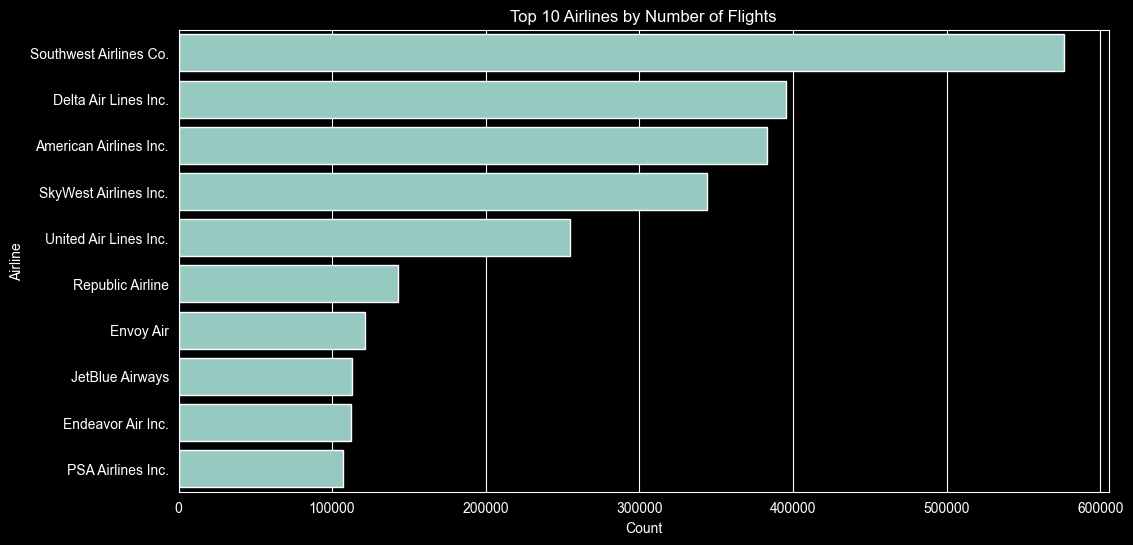

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Top 10 Airlines by number of flights
plt.figure(figsize=(12,6))
sns.countplot(
    y='AIRLINE',
    data=df_eda,
    order=df_eda['AIRLINE'].value_counts().index[:10]
)
plt.title("Top 10 Airlines by Number of Flights")
plt.xlabel("Count")
plt.ylabel("Airline")
plt.show()

#### 📈 Distribution of Numeric Features

We visualize the distribution of numeric features to understand their density, spread, and potential outliers.

**Features analyzed:** Flight times, distances, delays, and related metrics.

> **Visual:** Histograms with Kernel Density Estimate (KDE) curves

> **Purpose:** To explore distributions, identify skewness, and detect unusual values before feature engineering.

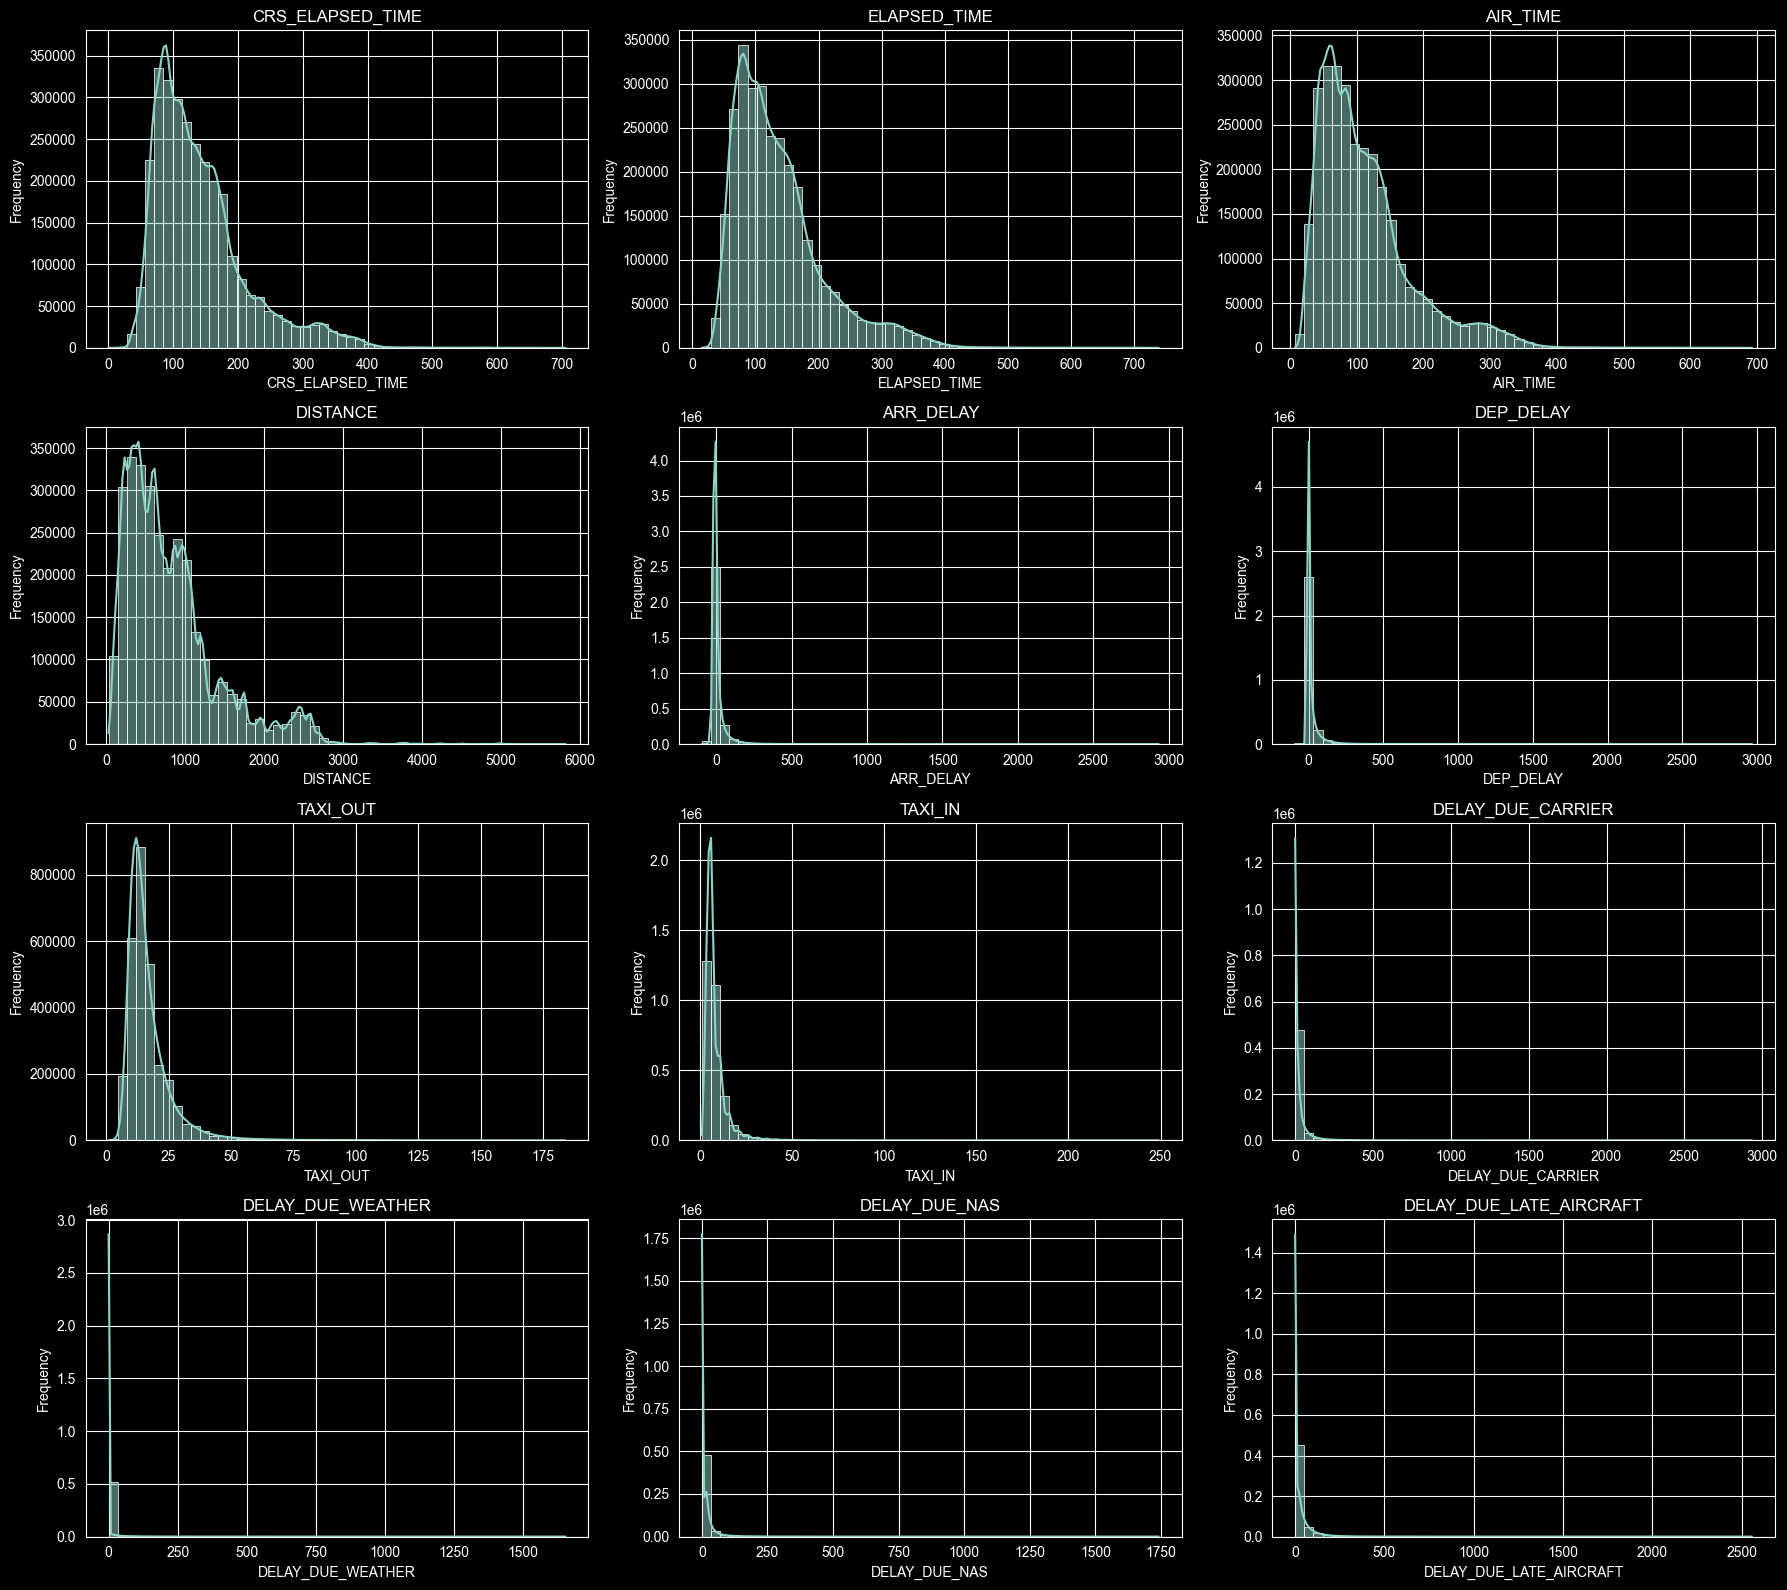

In [21]:
numeric_cols_eda = [
    'CRS_ELAPSED_TIME',  # scheduled flight time
    'ELAPSED_TIME',      # actual flight time
    'AIR_TIME',          # time in the air
    'DISTANCE',          # distance between airports
    'ARR_DELAY',         # arrival delay (target)
    'DEP_DELAY',         # departure delay
    'TAXI_OUT',          # time from gate to takeoff
    'TAXI_IN',           # time from landing to gate
    'DELAY_DUE_CARRIER', # delay caused by airline
    'DELAY_DUE_WEATHER', # weather delays
    'DELAY_DUE_NAS',     # national airspace system
    'DELAY_DUE_LATE_AIRCRAFT'  # late aircraft cascading delays
]

# Horizontal layout: 3 plots per row
n_cols = 3
n_rows = (len(numeric_cols_eda) + n_cols - 1) // n_cols

plt.figure(figsize=(6*n_cols, 4*n_rows))

for i, col in enumerate(numeric_cols_eda, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df_eda[col], bins=50, kde=True)
    plt.title(f"{col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

#### ⏱️ Arrival Delay by Airline

We visualize `ARR_DELAY` for each airline using boxplots to identify carriers with systematically higher or lower delays.

> **Visual:** Boxplots of arrival delay grouped by airline.
- Compare delay distributions across airlines.
- Detect airlines with extreme outliers or consistently high delays.
- Inform feature engineering and later modeling choices.

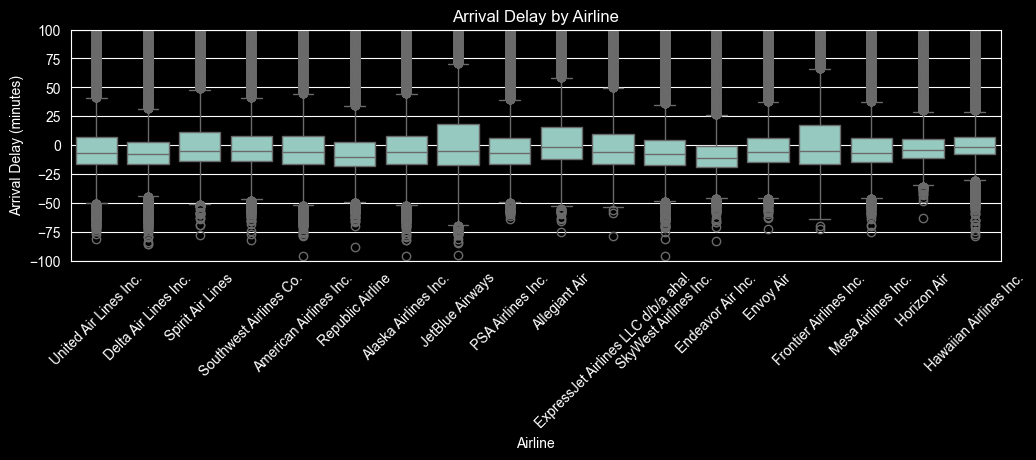

In [21]:
# Boxplots of ARR_DELAY by airline
plt.figure(figsize=(12,3))
sns.boxplot(x='AIRLINE', y='ARR_DELAY', data=df_eda)
plt.ylim(-100, 100)
plt.xticks(rotation=45)
plt.title("Arrival Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Arrival Delay (minutes)")
plt.show()

#### 🔗 Correlation Heatmap

We calculate pairwise correlations among numeric features and visualize them using a heatmap.

**Features considered:** All relevant numeric flight and delay metrics (times, distances, delays, taxi times, etc.)

**Purpose:**
- Identify linear relationships between features.
- Detect strong correlations to guide feature engineering.
- Spot potential multicollinearity issues before modeling.

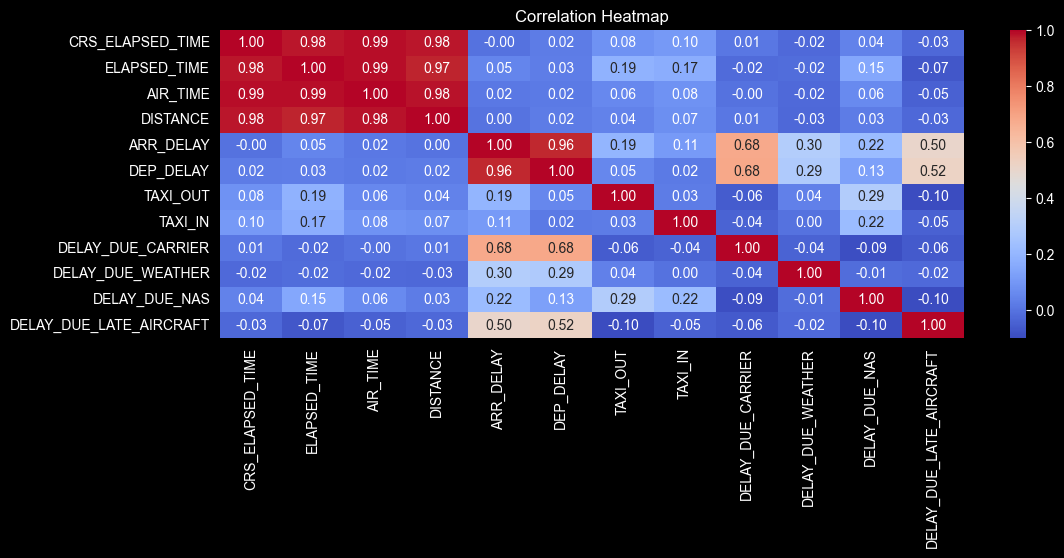

In [81]:
# Correlation matrix & heatmap
corr_matrix = df_eda[numeric_cols_eda].corr()

plt.figure(figsize=(12,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#### 📉 Scatter Plots of Key Features

We create scatter plots to explore relationships between key numeric features and arrival delays.
These plots help visualize trends, correlations, and potential patterns that may affect flight delays.

**Features compared include:** Distance, scheduled flight time, departure delay, taxi times, air time, and specific delay causes.

> **Visual:** Grid of scatter plots showing pairwise relationships between selected features and arrival delay.
> **Purpose:** To identify linear or non-linear relationships, clusters, and anomalies before feature engineering.

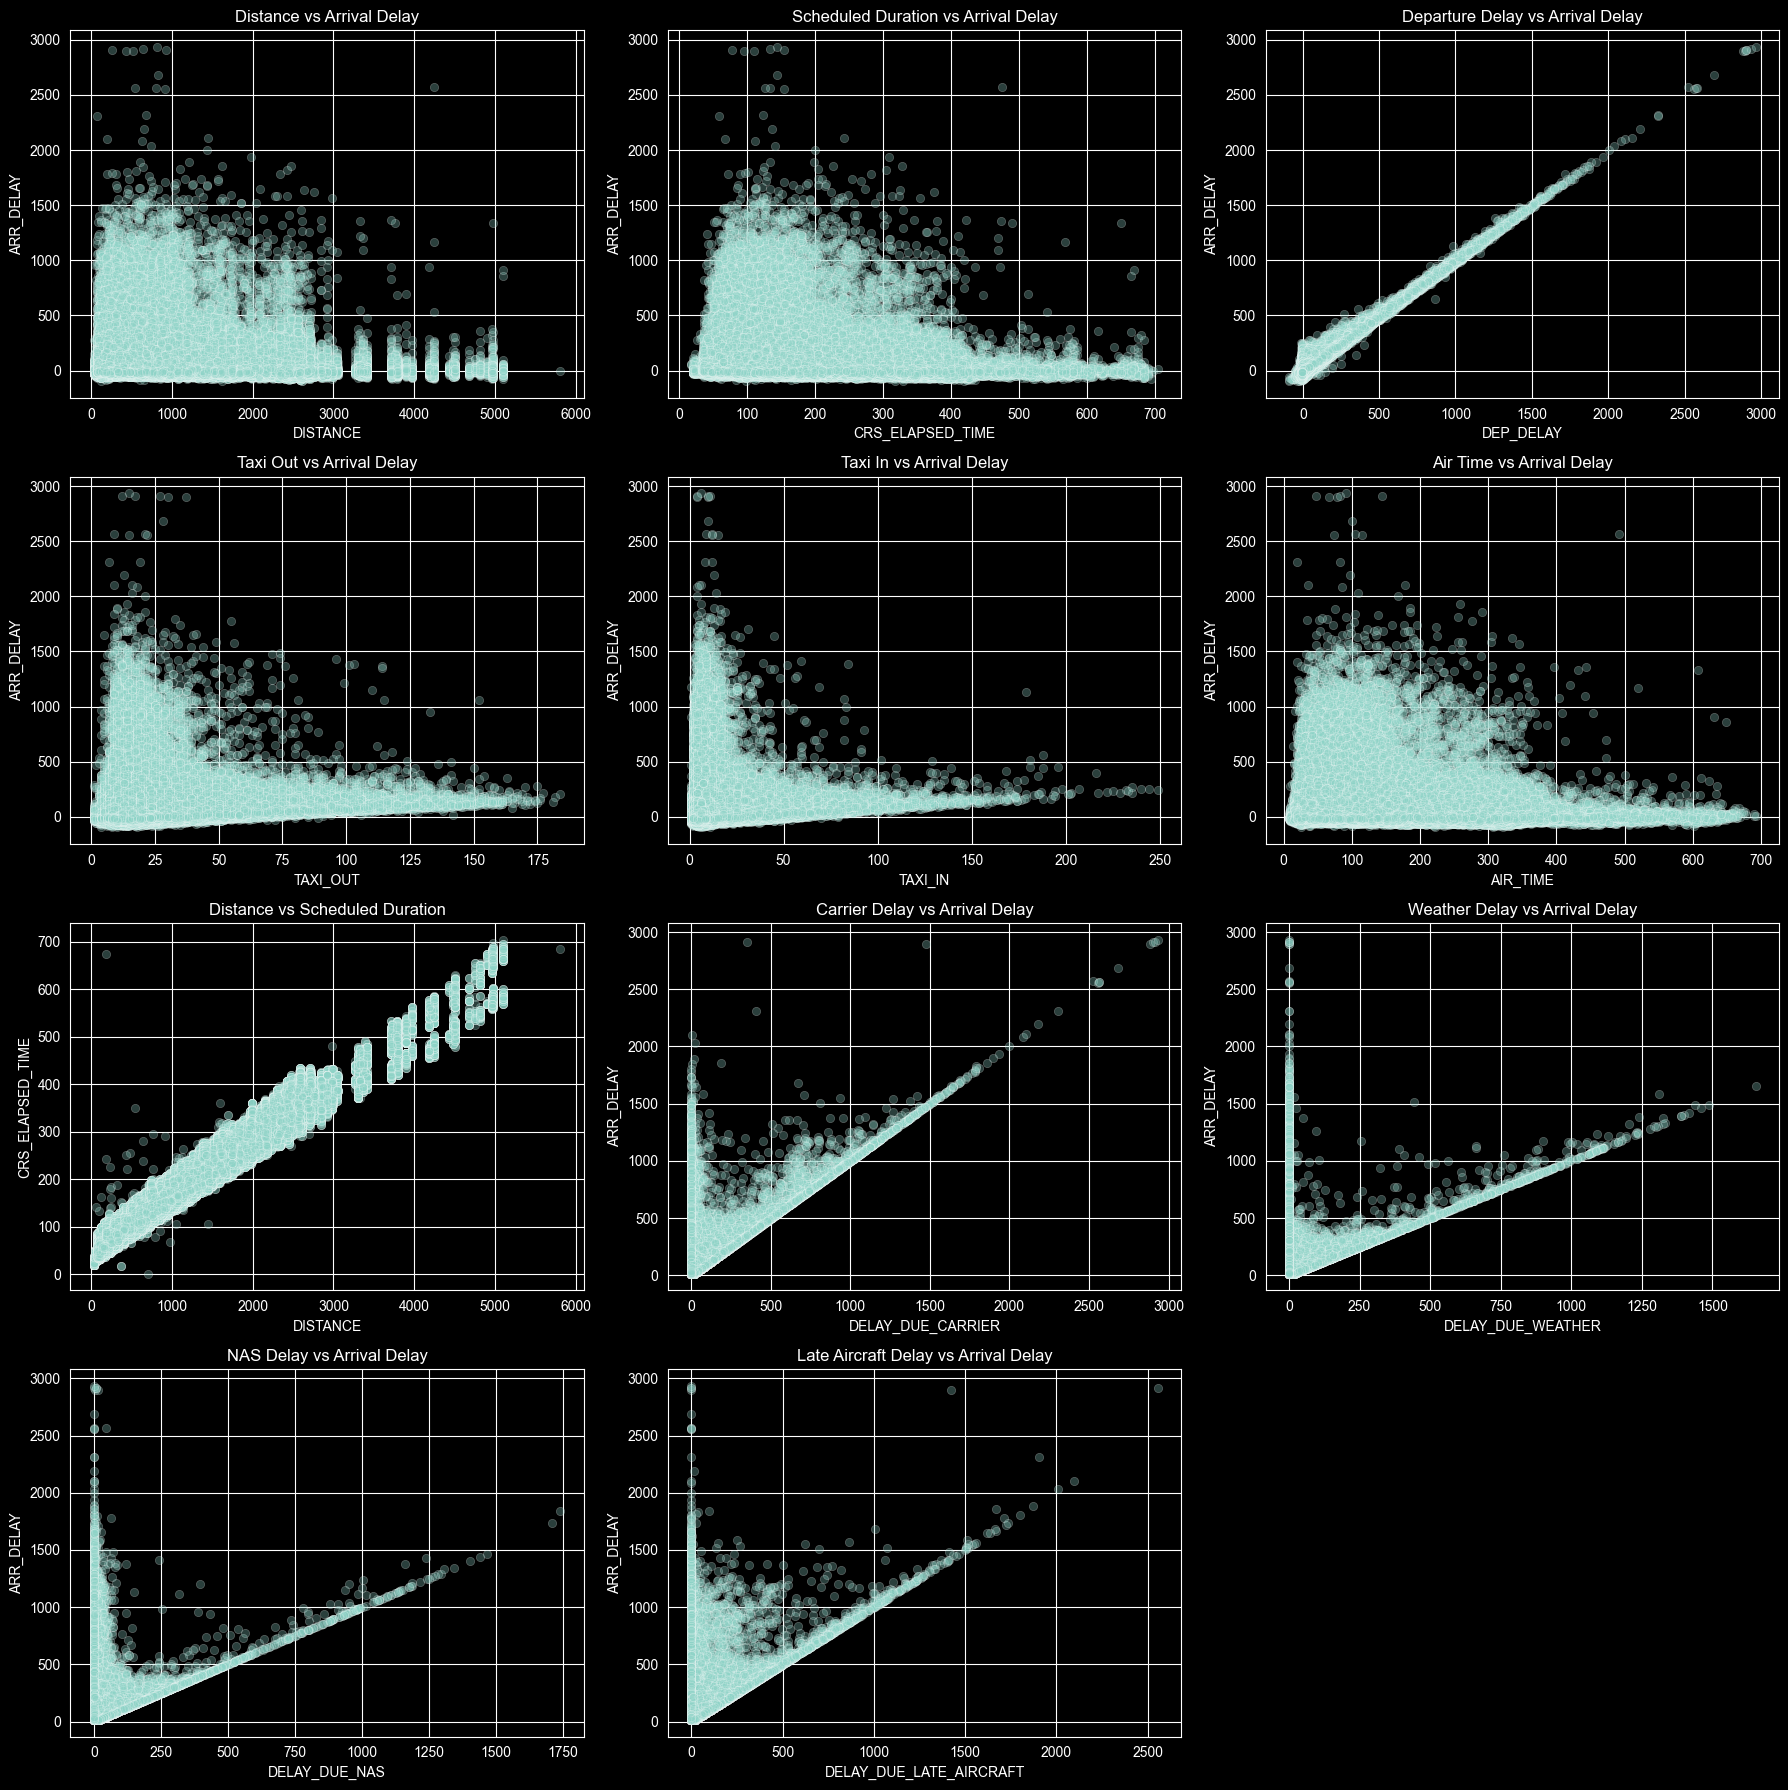

In [89]:
# Scatter plots side by side
scatter_plots = [
    ('DISTANCE', 'ARR_DELAY', "Distance vs Arrival Delay"),
    ('CRS_ELAPSED_TIME', 'ARR_DELAY', "Scheduled Duration vs Arrival Delay"),
    ('DEP_DELAY', 'ARR_DELAY', "Departure Delay vs Arrival Delay"),
    ('TAXI_OUT', 'ARR_DELAY', "Taxi Out vs Arrival Delay"),
    ('TAXI_IN', 'ARR_DELAY', "Taxi In vs Arrival Delay"),
    ('AIR_TIME', 'ARR_DELAY', "Air Time vs Arrival Delay"),
    ('DISTANCE', 'CRS_ELAPSED_TIME', "Distance vs Scheduled Duration"),
    ('DELAY_DUE_CARRIER', 'ARR_DELAY', "Carrier Delay vs Arrival Delay"),
    ('DELAY_DUE_WEATHER', 'ARR_DELAY', "Weather Delay vs Arrival Delay"),
    ('DELAY_DUE_NAS', 'ARR_DELAY', "NAS Delay vs Arrival Delay"),
    ('DELAY_DUE_LATE_AIRCRAFT', 'ARR_DELAY', "Late Aircraft Delay vs Arrival Delay")
]

rows = 4
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(18, 18))
axes = axes.flatten()  # Flatten to iterate easily

for i, (x_col, y_col, title) in enumerate(scatter_plots):
    sns.scatterplot(x=x_col, y=y_col, data=df_eda, alpha=0.3, ax=axes[i])
    axes[i].set_title(title)
    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_col)

# Remove any empty subplots if the grid is larger than the number of plots
for j in range(len(scatter_plots), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 🧩 Dimensionality Reduction with PCA

To explore the underlying structure of our dataset, I apply **Principal Component Analysis (PCA)** on the standardized numeric features:
`CRS_ELAPSED_TIME_std`, `DISTANCE_std`, `CRS_DEP_TIME_std`, `CRS_ARR_TIME_std`.

**Purpose of PCA:**
- Reduce the dimensionality of the data while retaining most of the variance.
- Visualize patterns and relationships between flights in a 2D space.
- Identify potential clusters or groupings by airline.

> **Visual:** Scatterplot of flights in the 2D PCA space, with points colored by airline.

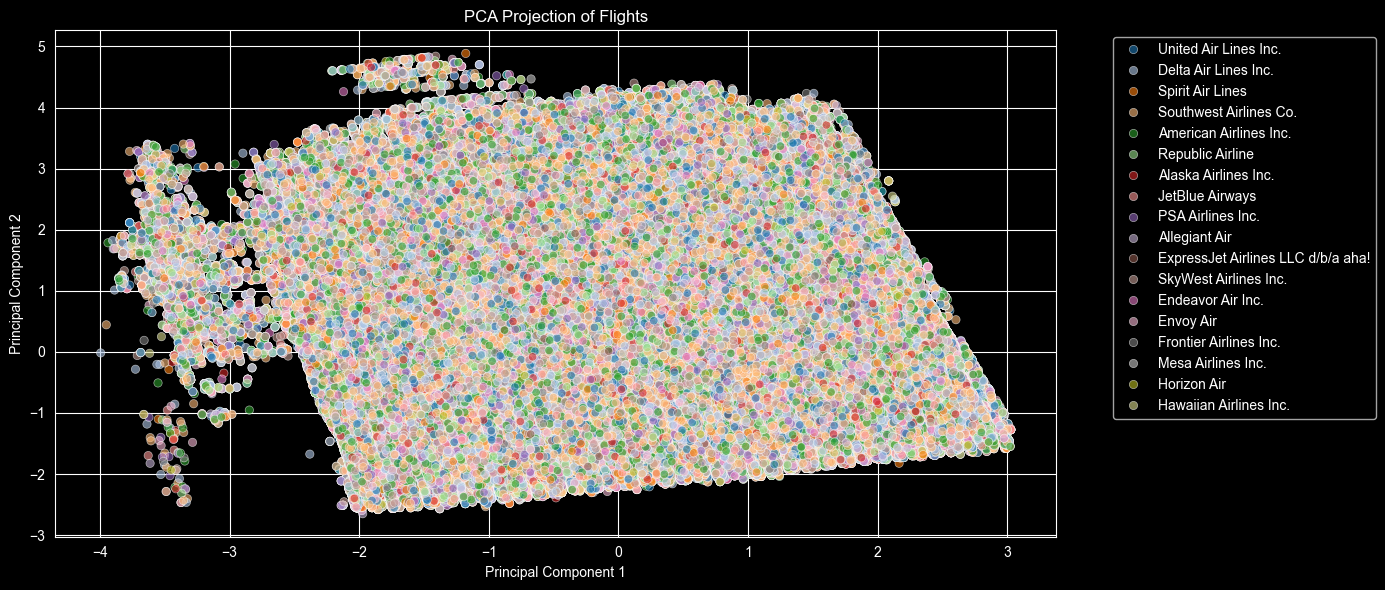

Explained variance ratio: [0.42550117 0.42407677]
Total variance explained: 0.8495779364616904


In [10]:
from sklearn.decomposition import PCA

# Columns to include in PCA
features_for_dr = df[['CRS_ELAPSED_TIME_std', 'DISTANCE_std', 'CRS_DEP_TIME_std', 'CRS_ARR_TIME_std']]

# Apply PCA (2 components)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features_for_dr)

# Create DataFrame for PCA results
df_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
df_pca['AIRLINE'] = df_eda.loc[features_for_dr.index, 'AIRLINE'].values

# Scatterplot of PCA projection
plt.figure(figsize=(14,6))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='AIRLINE',
    palette='tab20',
    alpha=0.6
)
plt.title("PCA Projection of Flights")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

# Explained variance
explained_var = pca.explained_variance_ratio_
print("Explained variance ratio:", explained_var)
print("Total variance explained:", explained_var.sum())

## 🌀 Dimensionality Reduction with UMAP

To further explore the structure of our dataset, we apply **UMAP (Uniform Manifold Approximation and Projection)** on the standardized numeric features:
`CRS_ELAPSED_TIME_std`, `DISTANCE_std`, `CRS_DEP_TIME_std`, `CRS_ARR_TIME_std`.

**Purpose of UMAP:**
- Reduce high-dimensional data to 2D while preserving both local and global structure.
- Visualize clusters, patterns, and relationships that may not be obvious in the original feature space.
- Complement PCA by capturing potential non-linear structures in the data.

> **Visual:** Scatterplot of flights in the 2D UMAP space, with points colored by airline.

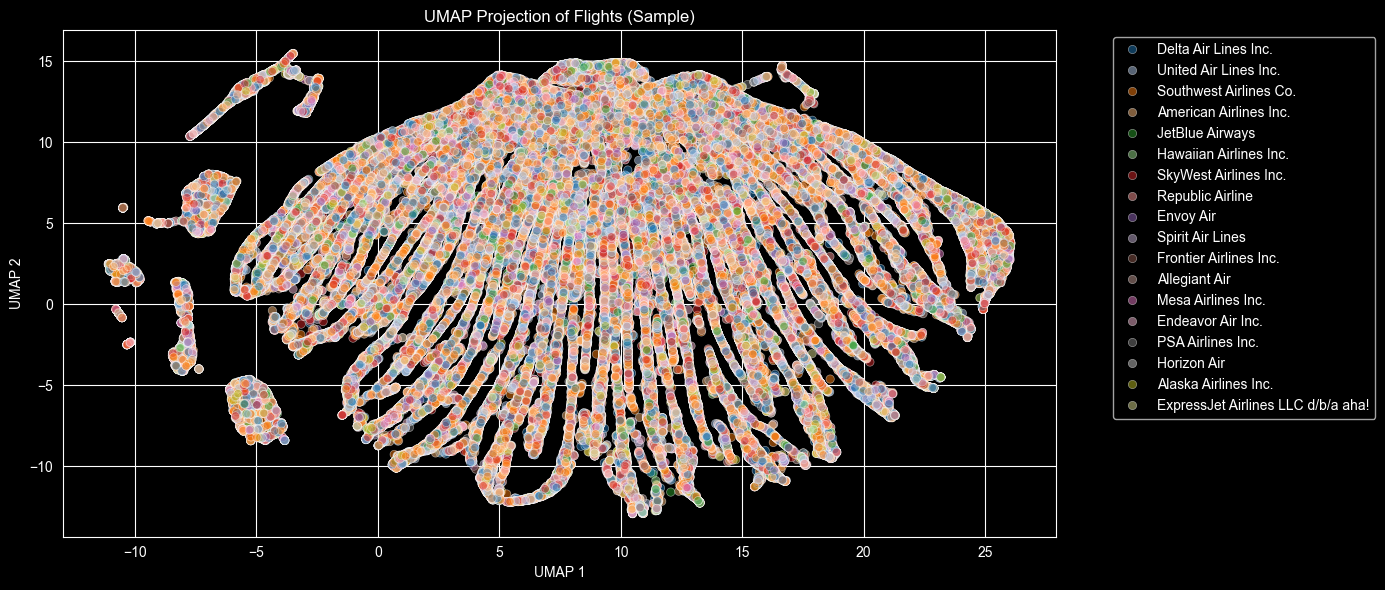

In [11]:
import umap
import warnings

# Suppress specific UMAP warning
warnings.filterwarnings(
    "ignore",
    message="n_jobs value 1 overridden to 1 by setting random_state"
)

# Sample features for faster computation
features_sample = features_for_dr.sample(200_000, random_state=42)
airline_sample = df_eda.loc[features_sample.index, 'AIRLINE'].values

# Initialize UMAP
umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=50,
    min_dist=0.1,
    random_state=42
)

# Fit and transform
umap_result = umap_reducer.fit_transform(features_sample)

# Create DataFrame for UMAP results
df_umap = pd.DataFrame(umap_result, columns=['UMAP1', 'UMAP2'])
df_umap['AIRLINE'] = airline_sample

# Plot UMAP projection (sample)
plt.figure(figsize=(14, 6))
sns.scatterplot(
    data=df_umap,
    x='UMAP1',
    y='UMAP2',
    hue='AIRLINE',
    palette='tab20',
    alpha=0.5
)
plt.title("UMAP Projection of Flights (Sample)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 🧠 2.2 Insights from Exploratory Data Analysis (EDA)

In this section, I summarize the key observations and patterns discovered from the dataset after preprocessing and initial exploratory analysis. These insights help guide feature engineering, model selection, and hypothesis testing.

## Dataset Distribution and Basic Statistics

Based on the descriptive statistics obtained from the dataset:

- The **average scheduled flight duration (CRS_ELAPSED_TIME)** is approximately **142 minutes**, with a median of **125 minutes**, indicating that most flights are relatively short to medium haul.
- The **average flight distance** is about **809 miles**, while the median distance is **651 miles**, suggesting that the dataset contains many medium-distance domestic routes.
- The **average arrival delay (ARR_DELAY)** is approximately **4.26 minutes**, while the **median delay is -7 minutes**, indicating that many flights arrive **slightly earlier than scheduled**, although delays still occur.
- The **standard deviation of arrival delays (≈51 minutes)** is relatively large compared to the mean, indicating **high variability in delay behavior**, with some flights experiencing substantial delays.
- The **maximum recorded arrival delay exceeds 2900 minutes**, which represents extreme outliers likely caused by severe operational disruptions such as weather events or cascading delays.
- The **minimum arrival delay of -96 minutes** indicates that some flights arrive significantly earlier than scheduled.
- The **minimum scheduled elapsed time is 1 minute**, which appears unrealistic for a commercial flight and likely represents an **outlier or data entry anomaly**.
- The **minimum recorded distance is 29 miles**, which is unusually small for commercial flights and may correspond to **very short regional routes or potential data inconsistencies**.
- The **maximum recorded distance is 5812 miles**, which is unusually large for typical domestic routes and may correspond to **long-haul routes (e.g., Alaska or Hawaii) or edge cases within the dataset**.

Overall, these statistics suggest that while most flights operate close to schedule, **there is considerable variability in delays**, making the dataset suitable for predictive modeling and delay classification tasks.

##  Airline Distribution in the Dataset

An analysis of the **top 10 airlines by number of flights** shows that **Southwest Airlines Co.** is the largest airline in the dataset, with **close to 600,000 recorded flights**. Following Southwest, **Delta Air Lines Inc.** and **American Airlines Inc.** appear as the **second and third-largest airlines**, each with **approximately 400,000 flights** recorded.

## Histogram Analysis

Based on the histograms of key numerical variables in the dataset, several patterns and distributions can be observed that provide additional context beyond summary statistics:

- The histogram of scheduled flight durations shows that the majority of flights have **CRS_ELAPSED_TIME between approximately 80 and 145 minutes**.
- The histogram of actual flight durations (ELAPSED_TIME) is **very similar to CRS_ELAPSED_TIME**, with most flights around 80 to 145 minutes. There are minor differences reflecting small variations between scheduled and actual flight times.
- The histogram of air time (AIR_TIME) is largely similar to the actual elapsed time, with most flights between 80 and 145 minutes. Minor differences may arise due to **variations in taxiing, takeoff, and landing durations**, which are included in ELAPSED_TIME but not in AIR_TIME.
- The histogram of flight distances (DISTANCE) shows that most flights cover **approximately 100–1,000 miles**, with the number of flights decreasing as distance increases. While a few flights exceed **4,000 miles**, these could represent long-haul routes (e.g., Alaska or Hawaii) and are technically plausible, though they can be considered **outliers in the dataset**.
- The histogram of arrival delays (ARR_DELAY) shows that **most flights arrive on time**, with the density peaking around **0 minutes**. A smaller proportion of flights arrive **slightly after schedule**, while even fewer arrive **earlier than scheduled**.
- The histogram of departure delays (DEP_DELAY) is very similar to ARR_DELAY, suggesting that **most flights depart on schedule**, with only a very small proportion of flights experiencing **minor departure delays**.
- The histogram of taxi-out times (TAXI_OUT) shows that most flights spend **approximately 12 to 20 minutes taxiing from the gate to takeoff**. This represents the typical pre-flight ground operations and minor variations in airport congestion or runway availability.
- The histogram of taxi-in times (TAXI_IN) shows that most flights spend **approximately 0 to 10 minutes taxiing from touchdown to the gate**, with a few flights taking slightly longer. This reflects normal variations in airport gate availability and ground operations.
- The histograms of delay cause (DELAY_DUE_CARRIER, DELAY_DUE_WEATHER, DELAY_DUE_NAS, and DELAY_DUE_LATE_AIRCRAFT) show **similar distributions**, with most flights experiencing **minimal delay from each cause**. Among these, **weather-related delays (DELAY_DUE_WEATHER)** and **National Airspace System delays (DELAY_DUE_NAS)** appear slightly more common, as indicated by slightly higher density peaks around small delay values.

## Arrival Delay Distribution by Airline

The boxplot analysis of **ARR_DELAY** for each airline shows that **most airlines have a median arrival delay close to 0 minutes**, indicating that flights typically arrive on time. A few airlines have **slightly negative medians**, meaning their flights tend to arrive a bit early on average. While there is a **long tail of outliers with delays above 25 minutes**, there are also **some outliers on the early side**, typically between **-25 and -80 minutes**, showing that extreme early arrivals, though less frequent, also occur across carriers.

## Feature Correlations and Observations

- **ARR_DELAY** shows the strongest correlation with **DEP_DELAY (0.96)**, as expected since departure delays largely drive arrival delays. Other notable correlations with ARR_DELAY include:
  - **DELAY_DUE_CARRIER:** 0.68
  - **DELAY_DUE_LATE_AIRCRAFT:** 0.50
  - **DELAY_DUE_WEATHER:** 0.30
  - **DELAY_DUE_NAS:** 0.22
  - **TAXI_OUT:** 0.19
  - **TAXI_IN:** 0.11

This confirms that **carrier issues, late aircraft, and weather are the main contributors** to arrival delays.<br>

- Some features are highly correlated with each other, as expected from their definitions:
  - **CRS_ELAPSED_TIME** and **ELAPSED_TIME:** 0.98
  - **AIR_TIME** and **DISTANCE:** 0.98–0.99

## Scatterplot Analysis

- The scatterplot of **DISTANCE vs ARR_DELAY** shows that flight distances are widely distributed from 0 to ~3000 miles. Most flights have **arrival delays ranging from slightly negative to around 1000 minutes**, with the majority concentrated at shorter distances and small delays. This indicates that while extreme delays can occur on any route, **most flights, regardless of distance, arrive close to schedule**.
- The scatterplot of **CRS_ELAPSED_TIME vs ARR_DELAY** shows that most flights with **scheduled durations from 0 to ~350 minutes** have a wide spread of arrival delays, mostly below 1500 minutes. Interestingly, for **longer flights above ~400 minutes**, arrival delays tend to cluster **closer to 0**, suggesting that longer flights are generally more punctual, possibly due to **built-in buffer times or more predictable scheduling**.
- The scatterplot of **DEP_DELAY vs ARR_DELAY** exhibits a strong positive correlation, showing that **later departures generally lead to later arrivals**. This highlights the significant impact of departure delays on overall flight punctuality.
- The scatterplots of **TAXI_OUT** and **TAXI_IN** versus **ARR_DELAY** show that most flights are **clustered at short taxi times (0–150 minutes) with arrival delays below 500 minutes**. There are also a few instances of **very short taxi times (<50 minutes) paired with unusually high delays (up to 1500 minutes)**, which likely represent **rare operational anomalies or extreme outliers**. Overall, while taxi times contribute to arrival delays, the majority of flights exhibit typical, moderate values.
- The scatterplot of **AIR_TIME versus CRS_ELAPSED_TIME** is nearly identical, showing a **very strong positive correlation**. This indicates that **actual in-air time closely follows the scheduled flight duration**, with minimal variation for most flights.
- The scatterplot of **DISTANCE versus CRS_ELAPSED_TIME** shows a **clear linear relationship**, indicating that **longer flights are scheduled with proportionally longer durations**, as expected.
- The scatterplots of **delay-related features versus ARR_DELAY** show a **distinct concentration near the origin (0,0)**, with a primary linear trend extending diagonally and a secondary vertical trend from 0. This indicates that **most flights experience minimal delays**, while a smaller set of flights exhibits **larger arrival delays that are strongly associated with specific delay causes**.

## PCA Analysis

The PCA scatterplot projects flights onto the first two principal components (PC1 and PC2), which together **explain approximately 85% of the variance** in the selected features: standardized scheduled duration, distance, and scheduled departure/arrival times.

- Each point represents a flight, with coloring by airline showing **some subtle clustering by airline**, although most airlines overlap considerably.
- This indicates that while **certain flight patterns are captured by the principal components**, most airlines operate across similar ranges of scheduled times and distances, so there is **no strong separation by carrier**.
- PCA confirms that the **majority of variation in the dataset is explained by scheduled duration and distance**, with scheduled times contributing less but still relevant structure.

## UMAP Analysis

The UMAP projection reduces the same standardized features used for PCA (**CRS_ELAPSED_TIME, DISTANCE, CRS_DEP_TIME, CRS_ARR_TIME**) into two dimensions, emphasizing both **local and global structure** in the dataset.

- Each point represents a flight, and coloring by airline shows **distinct, though overlapping clusters**, reflecting that some airlines have characteristic flight patterns in terms of distance and scheduled times.
- The mean positions of airlines in the UMAP space (UMAP1 and UMAP2) suggest **subtle grouping**, with airlines like **Horizon Air, Mesa Airlines, and Endeavor Air** slightly separated from the main cluster, while larger carriers like **Southwest, Delta, and American** are closer together.
- Compared to PCA, UMAP captures **non-linear relationships**, allowing patterns that were less visible in linear projections to emerge, highlighting operational similarities or differences between airlines.
- Overall, UMAP demonstrates that while many airlines overlap in scheduling and distance characteristics, there are **small but meaningful clusters** that could be explored further in clustering analyses.

---

# 🧪 2.3 Hypothesis Testing

To further understand the factors influencing flight delays, several statistical hypothesis tests were conducted. These tests evaluate relationships between flight characteristics, airlines, and operational factors that may impact arrival delays.

Different statistical methods were applied depending on the type of variables being analyzed. Pearson correlation tests were used to measure relationships between continuous variables, while t-tests and ANOVA tests were used to compare mean arrival delays across different groups such as airlines and departure times.

The goal of this analysis is to determine whether observed patterns in the dataset are statistically significant or simply the result of random variation.


### Hypothesis 1: Relationship Between Flight Distance and Arrival Delay

This hypothesis evaluates whether the **distance of a flight is associated with its arrival delay**.

**Null Hypothesis (H₀):**
There is **no correlation** between flight distance (**DISTANCE**) and arrival delay (**ARR_DELAY**).

**Alternative Hypothesis (H₁):**
There is a **significant correlation** between flight distance (**DISTANCE**) and arrival delay (**ARR_DELAY**).

The Pearson correlation test produced a correlation coefficient of **0.002**, indicating an **extremely weak relationship** between flight distance and arrival delay.

Although the **p-value (0.001)** is below the significance threshold of 0.05, suggesting statistical significance, the correlation coefficient is so close to zero that the relationship is **practically negligible**.

This result suggests that **flight distance does not meaningfully influence arrival delays**, and delays are likely driven by other operational or environmental factors.

In [20]:
from scipy.stats import pearsonr

# Ensure no missing values for arrival delay
df_hyp = df_hyp.dropna(subset=['ARR_DELAY'])
corr_coeff, p_value = pearsonr(df_hyp['DISTANCE'], df_hyp['ARR_DELAY'])

print(f"Pearson correlation coefficient: {corr_coeff:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    if abs(corr_coeff) < 0.05:
        print("✅ Statistically significant but correlation is extremely weak; practically negligible.\n")
    else:
        print("✅ Significant correlation: flight distance is associated with delays.\n")
else:
    print("❌ No significant correlation between distance and delay.\n")

Pearson correlation coefficient: 0.002
P-value: 0.001
✅ Statistically significant but correlation is extremely weak; practically negligible.



### Hypothesis 2: Comparison of Mean Arrival Delays Between Southwest Airlines Co. and Delta Air Lines Inc.

This hypothesis evaluates whether the **average arrival delays differ between the two largest airlines in the dataset**: **Southwest Airlines Co.** and **Delta Air Lines Inc.**.

**Null Hypothesis (H₀):**
The **mean arrival delay** for Southwest Airlines Co. is **equal** to that of Delta Air Lines Inc.

**Alternative Hypothesis (H₁):**
The **mean arrival delay** for Southwest Airlines Co. is **significantly different** from that of Delta Air Lines Inc.

A two-sample t-test was conducted, yielding the following results:

- **T-statistic:** 26.585
- **P-value:** 0.000

Since the **p-value is below 0.05**, we reject the null hypothesis, indicating a **statistically significant difference in mean arrival delays** between the two airlines.

This result suggests that **operational performance varies between airlines**, and the airline identity may be a relevant factor when predicting arrival delays.

In [19]:
# 2️⃣ Hypothesis 2: Comparison of Mean Arrival Delays Between Southwest Airlines Co. and Delta Air Lines Inc.
from scipy.stats import ttest_ind

# Extract arrival delays for the two airlines
sw_airline = df_hyp[df_hyp['AIRLINE'] == 'Southwest Airlines Co.']['ARR_DELAY']
delta_airline = df_hyp[df_hyp['AIRLINE'] == 'Delta Air Lines Inc.']['ARR_DELAY']

# Perform two-sample t-test
t_stat, p_value = ttest_ind(sw_airline, delta_airline)

# Print results
print(f"T-statistic: {t_stat:.3f}, P-value: {p_value:.3f}")

# Interpretation
if p_value < 0.05:
    print("✅ Significant difference in mean arrival delays between Southwest Airlines Co. and Delta Air Lines Inc.")
else:
    print("❌ No significant difference in mean arrival delays between Southwest Airlines Co. and Delta Air Lines Inc.")

T-statistic: 26.585, P-value: 0.000
✅ Significant difference in mean arrival delays between Southwest Airlines Co. and Delta Air Lines Inc.


### Hypothesis 3: Comparison of Mean Arrival Delays Across All Airlines

This hypothesis evaluates whether the **average arrival delays differ across all airlines** in the dataset.

**Null Hypothesis (H₀):**
All airlines have the **same mean arrival delay**.

**Alternative Hypothesis (H₁):**
At least one airline has a **mean arrival delay that is significantly different** from the others.

A one-way ANOVA test was conducted, yielding the following results:

- **F-statistic:** 669.892
- **P-value:** 0.000

Since the **p-value is below 0.05**, we reject the null hypothesis. This indicates that **significant differences exist in mean arrival delays between airlines**.

This result confirms that **airline identity plays an important role in arrival delays**, consistent with previous observations from the t-test between Southwest Airlines Co. and Delta Air Lines Inc.

In [18]:
# 3️⃣ Hypothesis 3: Comparison of Mean Arrival Delays Across All Airlines (ANOVA)
from scipy.stats import f_oneway

# Group arrival delays by airline
airline_groups = [df_hyp[df_hyp['AIRLINE'] == airline]['ARR_DELAY'] for airline in df_hyp['AIRLINE'].unique()]

# Perform one-way ANOVA
f_stat, p_value = f_oneway(*airline_groups)

# Print results
print(f"F-statistic: {f_stat:.3f}, P-value: {p_value:.3f}")

# Interpretation
if p_value < 0.05:
    print("✅ Significant differences exist in mean arrival delays between airlines.")
else:
    print("❌ No significant differences in mean arrival delays between airlines.")

F-statistic: 669.892, P-value: 0.000
✅ Significant differences exist in mean arrival delays between airlines.


### Hypothesis 4: Weather-Related Delays vs Arrival Delays

This hypothesis evaluates whether **weather-related delays contribute to overall arrival delays**.

**Null Hypothesis (H₀):**
There is **no correlation** between weather-related delays (**DELAY_DUE_WEATHER**) and arrival delays (**ARR_DELAY**).

**Alternative Hypothesis (H₁):**
There is a **significant correlation** between weather-related delays and arrival delays.

A Pearson correlation test was conducted, producing the following results:

- **Correlation coefficient:** 0.297
- **P-value:** 0.000

Since the **p-value is below 0.05**, we reject the null hypothesis. The **positive correlation coefficient indicates that weather-related delays are moderately associated with longer arrival delays**.

This result confirms that **weather is a meaningful factor affecting flight punctuality**, consistent with expectations from operational experience.

In [17]:
# 4️⃣ Hypothesis 4: Weather-related delays vs Arrival Delay

# Remove rows with missing weather delay data
df_weather = df_hyp.dropna(subset=['DELAY_DUE_WEATHER'])

# Compute Pearson correlation
corr_coeff, p_value = pearsonr(df_weather['DELAY_DUE_WEATHER'], df_weather['ARR_DELAY'])

# Print results
print(f"Pearson correlation coefficient: {corr_coeff:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpretation
if p_value < 0.05:
    print("✅ Weather-related delays significantly impact arrival delays.")
else:
    print("❌ Weather-related delays do not significantly impact arrival delays.")

Pearson correlation coefficient: 0.297
P-value: 0.000
✅ Weather-related delays significantly impact arrival delays.


### Hypothesis 5: Scheduled Departure Hour vs Arrival Delay

This hypothesis evaluates whether the **hour of scheduled departure affects arrival delays**.

**Null Hypothesis (H₀):**
Mean arrival delays are **the same across all scheduled departure hours**.

**Alternative Hypothesis (H₁):**
Mean arrival delays **differ across scheduled departure hours**.

A one-way ANOVA test was conducted, producing the following results:

- **F-statistic:** 1105.272
- **P-value:** 0.000

Since the **p-value is below 0.05**, we reject the null hypothesis. This indicates that **departure hour has a statistically significant impact on arrival delays**.

This result suggests that **flights departing at different times of day experience varying arrival delays**, likely due to factors such as **air traffic congestion, airport operational patterns, or scheduling practices**.

In [16]:
# 5️⃣ Hypothesis 5: Scheduled Departure Hour vs Arrival Delay

# Extract the departure hour directly from CRS_DEP_TIME
df_hyp['DEP_HOUR'] = df_hyp['CRS_DEP_TIME'] // 100

# Group arrival delays by departure hour
hour_groups = [df_hyp[df_hyp['DEP_HOUR'] == h]['ARR_DELAY'] for h in sorted(df_hyp['DEP_HOUR'].unique())]

# Perform one-way ANOVA
f_stat, p_value = f_oneway(*hour_groups)

# Print results
print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpretation
if p_value < 0.05:
    print("✅ Significant differences in mean arrival delays across departure hours.")
else:
    print("❌ No significant differences in mean arrival delays across departure hours.")

F-statistic: 1105.272
P-value: 0.000
✅ Significant differences in mean arrival delays across departure hours.


# 🛠️ 3. Feature Engineering

Feature engineering is the process of **creating new variables or transforming existing ones** to better capture patterns in the data and improve model performance.

In this section, we generate **additional features derived from the raw dataset**, based on insights from exploratory data analysis and domain knowledge. These new features aim to **enhance predictive power, reveal hidden relationships, and provide more granular information** about flight operations and delays.

The goal of this phase is to prepare a **richer feature set** for subsequent model selection and predictive analysis.


### Categorical Encoding: Airlines and Airports

- **AIRLINE_CODE**: Since the dataset contains a relatively small number of unique airlines, a **OneHotEncoder** was used. This creates a separate binary column for each airline, allowing the model to treat each airline as a distinct category without assuming any numeric ordering.

- **ORIGIN and DEST**: These columns contain a large number of unique airport codes. To avoid creating an excessively large number of features, a **LabelEncoder** was used. This assigns a unique integer to each airport, preserving uniqueness while keeping the feature space manageable.

After encoding, the original columns (`AIRLINE_CODE`, `ORIGIN`, `DEST`) were removed from the dataset to prevent redundancy.

In [18]:
# Categorical Encoding
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# Encode AIRLINE_CODE with OneHotEncoder
onehot_encoder = OneHotEncoder(sparse_output=False)
airline_encoded = onehot_encoder.fit_transform(df[['AIRLINE_CODE']])
encoded_airline_df = pd.DataFrame(
    airline_encoded,
    columns=onehot_encoder.get_feature_names_out(['AIRLINE_CODE'])
)
encoded_airline_df.columns = [col.replace('AIRLINE_CODE', 'encoded_airline') for col in encoded_airline_df.columns]
df = pd.concat([df, encoded_airline_df], axis=1)

# Encode ORIGIN and DEST with LabelEncoder
le_origin = LabelEncoder()
le_dest = LabelEncoder()
df['ORIGIN_label'] = le_origin.fit_transform(df['ORIGIN'])
df['DEST_label'] = le_dest.fit_transform(df['DEST'])

# Drop original categorical columns
df.drop(columns=['AIRLINE_CODE', 'ORIGIN', 'DEST'], inplace=True)

# Show head of newly created features
df_head_cols = list(encoded_airline_df.columns) + ['ORIGIN_label', 'DEST_label']
df[df_head_cols].head()

,encoded_airline_9E,encoded_airline_AA,encoded_airline_AS,encoded_airline_B6,encoded_airline_DL,encoded_airline_EV,encoded_airline_F9,encoded_airline_G4,encoded_airline_HA,encoded_airline_MQ,encoded_airline_NK,encoded_airline_OH,encoded_airline_OO,encoded_airline_QX,encoded_airline_UA,encoded_airline_WN,encoded_airline_YV,encoded_airline_YX,ORIGIN_label,DEST_label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,131,123
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,246,322
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,99,246
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,246,324
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,222,100


### Binning: Time, Duration, and Distance

To make continuous variables more interpretable and allow models to capture non-linear effects, several **binned features** were created:

1. **Departure Time (`dep_time_bin`)**:
   The hour of scheduled departure (`DEP_HOUR`) was divided into 4 bins:
   - Early Morning: 0–5
   - Morning: 6–11
   - Afternoon: 12–17
   - Evening/Night: 18–23

   This allows the model to capture patterns in delays that may occur during different parts of the day (e.g., rush hours, night flights).

2. **Scheduled Flight Duration (`flight_duration_bin`)**:
   The scheduled elapsed time (`CRS_ELAPSED_TIME`) was divided into 4 bins based on reasonable duration ranges:
   - Short: 0–59 min
   - Medium-Short: 60–119 min
   - Medium-Long: 120–239 min
   - Long: 240+ min

   Binning helps the model distinguish between short-haul and long-haul flights without assuming linear relationships.

3. **Flight Distance (`distance_bin`)**:
   Distance (`DISTANCE`) was divided into 4 bins based on quartiles:
   - Short: 0–25th percentile
   - Medium-Short: 25th–50th percentile
   - Medium-Long: 50th–75th percentile
   - Long: 75th–100th percentile

   This approach allows the model to differentiate flights by relative distance, capturing potential operational or logistical differences.

Binning converts continuous variables into categorical ranges, which can improve model performance for features that have non-linear effects on delays.

In [19]:
# Binning Features

# DEP_HOUR: Divide scheduled departure into 4 bins
df['DEP_HOUR'] = df['CRS_DEP_TIME'] // 100
hour_bins = [0, 6, 12, 18, 24]
hour_labels = ['Early Morning', 'Morning', 'Afternoon', 'Evening/Night']
df['dep_time_bin'] = pd.cut(df['DEP_HOUR'], bins=hour_bins, labels=hour_labels, right=False)

# CRS_ELAPSED_TIME: Flight duration bins
duration_bins = [0, 60, 120, 240, df['CRS_ELAPSED_TIME'].max() + 1]
duration_labels = ['Short', 'Medium-Short', 'Medium-Long', 'Long']
df['flight_duration_bin'] = pd.cut(df['CRS_ELAPSED_TIME'], bins=duration_bins, labels=duration_labels, right=False)

# DISTANCE: Flight distance bins based on quartiles
distance_bins = [0, df['DISTANCE'].quantile(0.25), df['DISTANCE'].quantile(0.5),
                 df['DISTANCE'].quantile(0.75), df['DISTANCE'].max()]
distance_labels = ['Short', 'Medium-Short', 'Medium-Long', 'Long']
df['distance_bin'] = pd.cut(df['DISTANCE'], bins=distance_bins, labels=distance_labels, include_lowest=True)

# Display head of newly created bins
df[['dep_time_bin', 'flight_duration_bin', 'distance_bin']].head()

,dep_time_bin,flight_duration_bin,distance_bin
0,Morning,Medium-Long,Long
1,Evening/Night,Medium-Long,Long
2,Morning,Medium-Short,Medium-Long
3,Afternoon,Long,Long
4,Evening/Night,Medium-Long,Medium-Long


### Interaction and Time-Based Features

To capture more complex relationships and temporal patterns in flight delays, several **new features** were created:

1. **Interaction Features**:
   - **Elapsed Time × Distance (`elapsed_x_distance`)**: The product of scheduled flight duration and distance.
     This feature captures combined effects of longer flights and greater distances that might influence delays.
   - **Departure Hour × Elapsed Time (`dep_hour_x_elapsed`)**: Multiplying the departure hour by flight duration.
     This can highlight patterns such as longer flights departing during peak hours being more prone to delays.

2. **Time-Based Features**:
   - **Day of the Week (`DAY_OF_WEEK`)**: Encodes the day of the week (0 = Monday, 6 = Sunday) to capture weekly operational patterns.
   - **Month (`MONTH`)**: Captures seasonal variations in flight delays.
   - **Weekend Indicator (`IS_WEEKEND`)**: Binary feature indicating if the flight occurs on a weekend (Saturday/Sunday), which can affect airport congestion and staffing.
   - **Rush Hour Indicator (`IS_RUSH_HOUR`)**: Binary feature indicating if the scheduled departure falls between 16:00–20:00, when air traffic congestion is typically higher.

These engineered features are intended to give the model **more informative inputs**, especially for non-linear patterns and temporal effects.

In [20]:
# Interaction and Time-Based Features

# Interaction features
df['elapsed_x_distance'] = df['CRS_ELAPSED_TIME'] * df['DISTANCE']
df['dep_hour_x_elapsed'] = df['DEP_HOUR'] * df['CRS_ELAPSED_TIME']

# Time-based features
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['DAY_OF_WEEK'] = df['FL_DATE'].dt.dayofweek
df['MONTH'] = df['FL_DATE'].dt.month
df['IS_WEEKEND'] = df['DAY_OF_WEEK'].isin([5, 6]).astype(int)
df['IS_RUSH_HOUR'] = df['DEP_HOUR'].between(16, 20).astype(int)

# Remove original date column after extracting features
df.drop(columns=['FL_DATE'], inplace=True)

# Show head of new features
df[['DEP_HOUR','elapsed_x_distance', 'dep_hour_x_elapsed','DAY_OF_WEEK','MONTH','IS_WEEKEND','IS_RUSH_HOUR']].head()

,DEP_HOUR,elapsed_x_distance,dep_hour_x_elapsed,DAY_OF_WEEK,MONTH,IS_WEEKEND,IS_RUSH_HOUR
0,11,198090.0,2046.0,2,1,0,0
1,21,328765.0,4935.0,5,11,1,0
2,9,80240.0,1062.0,4,7,0,0
3,16,413140.0,4160.0,0,3,0,1
4,18,178285.0,3258.0,6,2,1,1


# 🤖 4. Model Selection

After completing data preprocessing, exploratory analysis, hypothesis testing, and feature engineering, the next step is to evaluate **predictive models** that can estimate flight arrival delays.

The goal of this phase is to determine which types of models are suitable for the problem and to establish a **baseline performance** that future models can be compared against. Since the target variable (**ARR_DELAY**) is continuous, this task is treated as a **regression problem**.

To begin, a **Linear Regression model** was implemented as a baseline approach.


### Linear Regression Model

Linear Regression is one of the most fundamental supervised learning algorithms used for regression tasks. It attempts to model the relationship between a dependent variable and multiple independent variables by fitting a linear equation to the observed data.

Before training the model, the dataset was divided into **training and testing sets** using an 80/20 split:
- **Training set (80%)**: used to train the model
- **Testing set (20%)**: used to evaluate model performance on unseen data

Several evaluation metrics were used to assess the model's performance:

- **MAE (Mean Absolute Error):** Average absolute difference between predicted and actual delays.
- **RMSE (Root Mean Squared Error):** Measures prediction error while penalizing larger errors more strongly.
- **R² (Coefficient of Determination):** Indicates how much variance in arrival delays is explained by the model.


### Model Evaluation

After training the Linear Regression model, the following results were obtained:

- **MAE:** 23.741
- **RMSE:** 51.188
- **R²:** 0.013

The **Mean Absolute Error (MAE)** indicates that, on average, the model's predictions differ from the actual arrival delays by approximately **23.7 minutes**.

The **Root Mean Squared Error (RMSE)** is higher at about **51.2 minutes**, suggesting that some predictions contain **large errors**, since this metric penalizes larger deviations more strongly.

The **R² score (0.013)** is very close to zero, meaning that the model explains **only about 1.3% of the variance** in arrival delays. This indicates that the linear regression model has **very limited predictive power** for this problem.

Overall, these results suggest that the relationship between the available features and arrival delays is **not well captured by a simple linear model**. Flight delays are likely influenced by **more complex, non-linear factors** such as weather conditions, air traffic congestion, airport operations, and other external variables.

Therefore, while Linear Regression serves as a useful **baseline model**, more advanced models or additional features may be required to achieve better predictive performance.


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features and target
X = df.drop(columns=['ARR_DELAY','CRS_DEP_TIME','dep_time_bin','flight_duration_bin','distance_bin',
                     'CRS_ELAPSED_TIME_minmax','DISTANCE_minmax'])
y = df['ARR_DELAY']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression complete.")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2: {r2:.3f}")


Linear Regression complete.
MAE: 23.741
RMSE: 51.188
R2: 0.013


### Random Forest Regression Model

To explore whether a more complex model could better capture patterns in the dataset, a **Random Forest Regressor** was implemented. This **ensemble method** builds multiple decision trees and aggregates their predictions, allowing it to model **non-linear relationships and interactions** that a simple linear model cannot.

The model was trained using the same **80/20 training–testing split** as the Linear Regression baseline to ensure a fair comparison.

### Model Evaluation

The Random Forest model achieved the following results:

- **MAE:** 23.485
- **RMSE:** 51.164
- **R²:** 0.013

Performance is very similar to the Linear Regression baseline, with only slight differences in MAE and RMSE.

### Feature Importance Analysis

Random Forest models provide estimates of **feature importance**, highlighting which variables contribute most to predictions. The top features identified include:

- **DAY_OF_WEEK**
- **MONTH**
- **CRS_DEP_TIME (standardized)**
- **elapsed_x_distance**
- **CRS_DEP_TIME (min-max scaled)**
- **dep_hour_x_elapsed**

These results underscore the significance of **temporal variables and engineered interaction features** in predicting flight arrival delays.

Random Forest Results:
MAE: 23.485
RMSE: 51.164
R2: 0.013


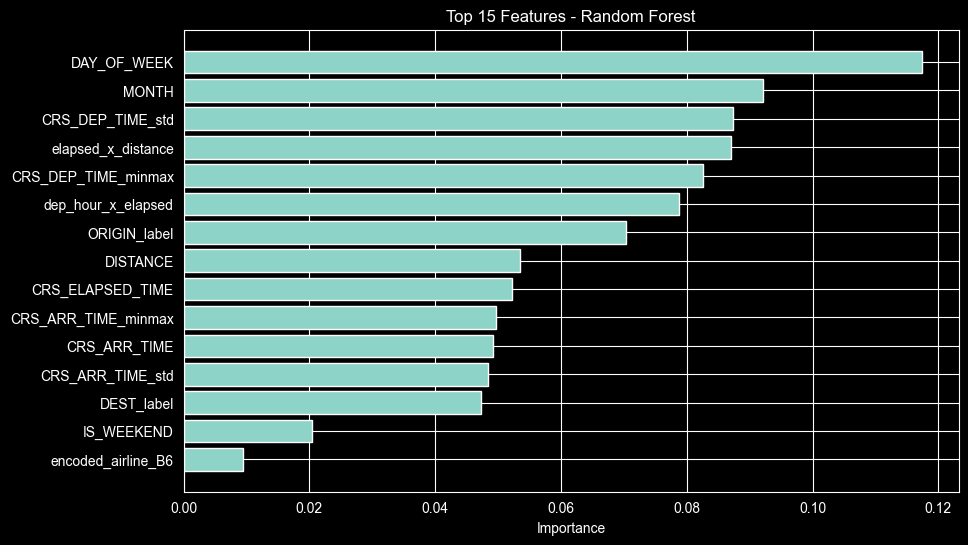

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Features and target
X = df.drop(columns=['ARR_DELAY','CRS_DEP_TIME','dep_time_bin','flight_duration_bin','distance_bin',
                     'CRS_ELAPSED_TIME_std','DISTANCE_std','CRS_ELAPSED_TIME_minmax','DISTANCE_minmax'])
y = df['ARR_DELAY']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Results:")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2: {r2:.3f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feature_importance['feature'].head(15)[::-1],
         feature_importance['importance'].head(15)[::-1])
plt.xlabel("Importance")
plt.title("Top 15 Features - Random Forest")
plt.show()


### Model Comparison and Discussion

To evaluate the predictive performance of the models, the results from **Linear Regression** and **Random Forest Regression** were compared using the same evaluation metrics.

| Model | MAE | RMSE | R² |
|------|------|------|------|
| Linear Regression | 23.741 | 51.188 | 0.013 |
| Random Forest | 23.485 | 51.164 | 0.013 |

Both models produced **very similar performance results**. While the Random Forest model achieved a slightly lower MAE and RMSE, the difference was minimal and the **R² score remained extremely low for both models**.

An **R² value of approximately 0.013** indicates that the models explain only about **1.3% of the variance in arrival delays**. This suggests that the available features in the dataset provide **limited predictive power for accurately estimating flight arrival delays**.

One possible explanation is that flight delays are influenced by **many external factors that are not captured in the dataset**, such as:
- real-time weather conditions
- air traffic control decisions
- airport congestion
- operational disruptions
- maintenance issues

Despite the limited predictive performance, the modeling process still provided useful insights. The **Random Forest feature importance analysis** highlighted that variables such as **day of the week, month, scheduled departure time, and engineered interaction features** contributed most to the model's predictions.

Overall, this analysis demonstrates that while machine learning models can identify **patterns and influential factors**, predicting exact arrival delays remains a **complex problem requiring richer operational and real-time data**.
